# Rock vs Mine Prediction — Logistic Regression **from scratch**

This is the same Sonar dataset and problem as the sklearn version, but every piece of the model — the sigmoid, the cost function, the gradients, the training loop, and the prediction step — is implemented by hand with plain NumPy. No `sklearn.linear_model`, no `.fit()` black box.

Run the cells top to bottom, one at a time, and read the comments — each one is a building block you can inspect before moving to the next.

## 1. Importing the Dependencies

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Data Collection and Data Processing


In [7]:
# loading the dataset to a pandas Dataframe
sonar_data = pd.read_csv("C:/Users/JONATHAN/Downloads/python/Data/Machine Leraning/practical learning videos/Copy of sonar data.csv", header=None)


In [9]:
sonar_data.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [11]:
# number of rows and columns
sonar_data.shape


(208, 61)

In [13]:
sonar_data.describe()  # statistical measures of the data

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [15]:
sonar_data[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

M --> Mine

R --> Rock

In [17]:
sonar_data.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


In [19]:
# separating data and Labels
X = sonar_data.drop(columns=60, axis=1).values   # convert straight to a NumPy array
Y_raw = sonar_data[60].values


### Encoding the labels

Gradient descent needs numbers, not letters. `LogisticRegression` in sklearn handled the 'R'/'M' strings for you internally — here we do it ourselves: **R -> 0, M -> 1**.

In [25]:
Y = np.where(Y_raw == 'M', 1, 0)
print(X.shape, Y.shape)
print(Y[:10])


(208, 60) (208,)
[0 0 0 0 0 0 0 0 0 0]


## 3. Training and Test data


In [29]:
def train_test_split_scratch(X, y, test_size=0.1, random_state=1):
    """
    Stratified train/test split, implemented from scratch.
    Splits each class separately so the R/M ratio is preserved in both sets,
    then shuffles and recombines — mirroring sklearn's stratify=y behaviour.
    """
    rng = np.random.RandomState(random_state)
    train_idx, test_idx = [], []

    for c in np.unique(y):
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        n_test = int(round(len(c_idx) * test_size))
        test_idx.extend(c_idx[:n_test])
        train_idx.extend(c_idx[n_test:])

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


In [31]:
X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.1, random_state=1)


In [33]:
print(X.shape, X_train.shape, X_test.shape)

(208, 60) (187, 60) (21, 60)


### Feature scaling


In [37]:
def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1  # guard against divide-by-zero on constant columns
    return mean, std

def standardize_apply(X, mean, std):
    return (X - mean) / std

train_mean, train_std = standardize_fit(X_train)
X_train_scaled = standardize_apply(X_train, train_mean, train_std)
X_test_scaled = standardize_apply(X_test, train_mean, train_std)


## 4. Logistic Regression — built from scratch

We'll build this in small pieces so each mathematical step is visible: the sigmoid, the cost (binary cross-entropy), the gradients, and finally the gradient descent loop that ties them together.

### 4.1 The sigmoid function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Squashes any real number into a probability between 0 and 1.

In [40]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [42]:
# quick sanity check
print(sigmoid(0))     # should be 0.5
print(sigmoid(100))   # should be ~1
print(sigmoid(-100))  # should be ~0


0.5
1.0
3.7200759760208356e-44


### 4.2 Initializing parameters


In [45]:
def initialize_parameters(n_features):
    w = np.zeros(n_features)
    b = 0.0
    return w, b


### 4.3 The cost function (binary cross-entropy)

$$J(w,b) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\Big]$$

This measures how wrong the model's predicted probabilities are. We clip predictions away from exactly 0 or 1 to avoid `log(0)`.

In [47]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)

    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    cost = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost


### 4.4 The gradients

These come straight from the derivative of the cost function above:

$$\frac{\partial J}{\partial w} = \frac{1}{m}X^T(\hat{y}-y) \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum(\hat{y}-y)$$

In [49]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)

    dw = (1 / m) * np.dot(X.T, (y_hat - y))
    db = (1 / m) * np.sum(y_hat - y)
    return dw, db


### 4.5 Gradient descent

Repeatedly: compute gradients -> step the parameters in the opposite direction -> repeat. We track the cost every 100 iterations so we can watch it fall.

In [53]:
def gradient_descent(X, y, w, b, learning_rate, num_iterations, print_every=200):
    cost_history = []

    for i in range(num_iterations):
        dw, db = compute_gradients(X, y, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % print_every == 0 or i == num_iterations - 1:
            cost = compute_cost(X, y, w, b)
            cost_history.append((i, cost))
            print(f'Iteration {i:5d} | Cost: {cost:.6f}')

    return w, b, cost_history


In [96]:
print("Final bias (b):", b)
print("Final weights (w):", w)

Final bias (b): 0.7390773410549726
Final weights (w): [ 0.78950152  0.29599938 -0.93037889  1.03685455 -0.20985722 -0.22319453
 -0.6707804  -0.76341882  0.69459649  0.06690181  0.85161972  1.1690041
 -0.10813711 -0.16174225 -0.17521956 -0.55716227 -0.53991781  0.34497158
  0.38965415  0.20921328  0.04445501  0.45537766  0.55209497  0.6863591
  0.06277549 -0.39899855  0.03270797  0.19381538  0.37404283  0.61480408
 -1.7332007   0.50003289  0.55876306 -0.30930733 -0.01293657 -0.75813681
 -1.27868652  0.47679941  0.56805425 -0.94311555 -0.06667678 -0.04243413
  0.31295446  0.531704    0.69747934  0.53366602  0.24777639  0.73734518
  1.22904193 -1.26416246  0.41761917  0.65812775  0.42077152  0.6321589
 -0.26558042 -0.08143949 -0.36206416  0.42086822  0.13666985  0.22287842]


### 4.6 Prediction

Once we have `w` and `b`, predicting is just: compute the probability, threshold it at 0.5.

In [55]:
def predict_proba(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)


### 4.7 Accuracy metric

Our own version of `accuracy_score` — the fraction of predictions that match the true labels.

In [57]:
def accuracy_score_scratch(y_true, y_pred):
    return np.mean(y_true == y_pred)


## 5. Model Training

Now we wire all the pieces together: initialize parameters, then run gradient descent on the *scaled* training data. Try changing `learning_rate` and `num_iterations` afterward and re-running to build intuition for how they affect convergence.

In [94]:
n_features = X_train_scaled.shape[1]
w, b = initialize_parameters(n_features)

learning_rate = 0.05
num_iterations = 3000

w, b, cost_history = gradient_descent(X_train_scaled, Y_train, w, b, learning_rate, num_iterations)


Iteration     0 | Cost: 0.664094
Iteration   200 | Cost: 0.339220
Iteration   400 | Cost: 0.301691
Iteration   600 | Cost: 0.281323
Iteration   800 | Cost: 0.267716
Iteration  1000 | Cost: 0.257658
Iteration  1200 | Cost: 0.249747
Iteration  1400 | Cost: 0.243258
Iteration  1600 | Cost: 0.237774
Iteration  1800 | Cost: 0.233034
Iteration  2000 | Cost: 0.228867
Iteration  2200 | Cost: 0.225153
Iteration  2400 | Cost: 0.221805
Iteration  2600 | Cost: 0.218760
Iteration  2800 | Cost: 0.215969
Iteration  2999 | Cost: 0.213406


### Visualizing convergence

The cost should fall steadily and flatten out. If it oscillates or increases, the learning rate is too high; if it barely moves, it's too low or needs more iterations.

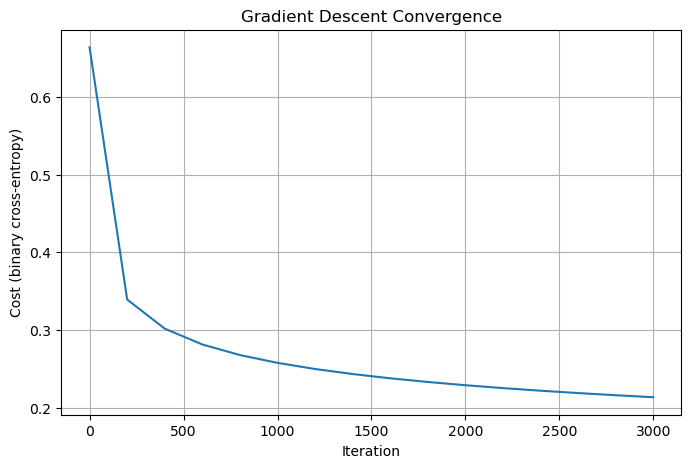

In [61]:
iterations, costs = zip(*cost_history)
plt.figure(figsize=(8, 5))
plt.plot(iterations, costs)
plt.xlabel('Iteration')
plt.ylabel('Cost (binary cross-entropy)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()


## 6. Model Evaluation

In [67]:
# accuracy on training data
X_train_prediction = predict(X_train_scaled, w, b)
training_data_accuracy = accuracy_score_scratch(Y_train, X_train_prediction)


In [69]:
print('Accuracy on training data : ', training_data_accuracy)

Accuracy on training data :  0.9197860962566845


In [71]:
# accuracy on test data
X_test_prediction = predict(X_test_scaled, w, b)
test_data_accuracy = accuracy_score_scratch(Y_test, X_test_prediction)


In [73]:
print('Accuracy on test data : ', test_data_accuracy)

Accuracy on test data :  0.9047619047619048


## 7. Making a Predictive System

Same input as before. Remember: any new data point must go through the **same standardization** (using the training set's mean/std) before it's fed into the model — never re-fit the scaler on new data.

In [75]:
input_data = (0.0307,0.0523,0.0653,0.0521,0.0611,0.0577,0.0665,0.0664,0.1460,0.2792,0.3877,0.4992,0.4981,0.4972,0.5607,0.7339,0.8230,0.9173,0.9975,0.9911,0.8240,0.6498,0.5980,0.4862,0.3150,0.1543,0.0989,0.0284,0.1008,0.2636,0.2694,0.2930,0.2925,0.3998,0.3660,0.3172,0.4609,0.4374,0.1820,0.3376,0.6202,0.4448,0.1863,0.1420,0.0589,0.0576,0.0672,0.0269,0.0245,0.0190,0.0063,0.0321,0.0189,0.0137,0.0277,0.0152,0.0052,0.0121,0.0124,0.0055)

# changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# apply the SAME scaling used on the training data
input_data_scaled = standardize_apply(input_data_reshaped, train_mean, train_std)

prediction = predict(input_data_scaled, w, b)
print(prediction)

if prediction[0] == 0:
    print('The object is a Rock')
else:
    print('The object is a Mine')


[1]
The object is a Mine


## 8. (Optional) Compare against sklearn


In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
#
# sk_model = LogisticRegression()
# sk_model.fit(X_train_scaled, Y_train)
# print('sklearn train accuracy:', accuracy_score(Y_train, sk_model.predict(X_train_scaled)))
# print('sklearn test accuracy:', accuracy_score(Y_test, sk_model.predict(X_test_scaled)))
